# Day 3 – Volatility & Risk Analysis (EURUSD)

## Objective
This project focuses on understanding the risk characteristics of EURUSD by analyzing volatility, rolling risk, and downside exposure.

## Dataset
EURUSD dataset from Day 1.

## Tools
Python, pandas, numpy, matplotlib

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
# Creating Output Folders
os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [4]:
# Load the Dataset
file_path = r"C:\Users\THIS PC\Desktop\quant-finance-portfolio\day-01-market-data-analysis\data\eurusd_daily_raw.csv"
df = pd.read_csv(file_path, index_col=0)

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.head()

,open,high,low,close,simple_return,log_return,cum_return,equity_curve,rolling_peak,drawdown
2007-01-17,1.2917,1.2950,1.2898,1.2938,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-18,1.2938,1.2976,1.2896,1.2963,0.001932,0.001930,0.001932,1.001932,1.001932,0.000000
2007-01-19,1.2963,1.3001,1.2914,1.2961,-0.000154,-0.000154,0.001778,1.001778,1.001932,-0.000154
2007-01-22,1.2959,1.2977,1.2923,1.2949,-0.000926,-0.000926,0.000850,1.000850,1.001932,-0.001080
2007-01-23,1.2949,1.3044,1.2929,1.3026,0.005946,0.005929,0.006802,1.006802,1.006802,0.000000


In [5]:
#Basic Volatility
#Daily volatility (std of returns)
daily_vol = df["simple_return"].std()
print("Daily Volatility:", daily_vol)

#Annualized Volatility
annual_vol = daily_vol * np.sqrt(252)
print("Annualized Volatility:", annual_vol)

Daily Volatility: 0.005571033723186153
Annualized Volatility: 0.08843741866262887


In [6]:
#Rolling Volatility :shows how risk changes over time
df["rolling_vol_20"] = df["simple_return"].rolling(window=20).std() * np.sqrt(252)

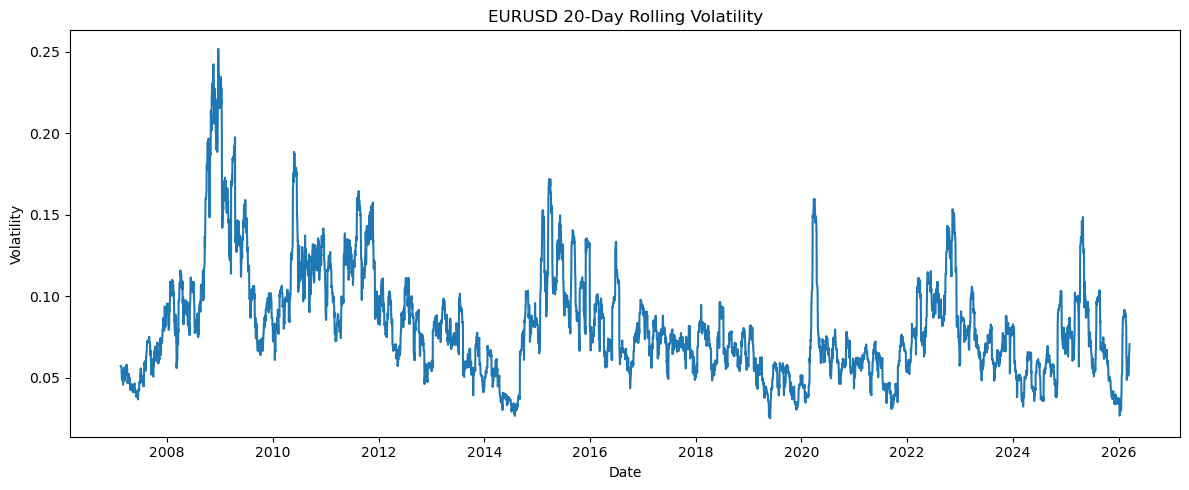

In [7]:
#Visualization 
#Plot Rolling Volatility
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["rolling_vol_20"])
plt.title("EURUSD 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.tight_layout()
plt.savefig("outputs/charts/day03_rolling_volatility.png")
plt.show()

In [9]:
#Value at Risk (VaR)
#Historical VaR (95%)
var_95 = np.percentile(df["simple_return"].dropna(), 5)
print("VaR (95%):", var_95)

'''There is a 5% chance of losing more than this amount in a day”
'''

VaR (95%): -0.00869406442883737


'There is a 5% chance of losing more than this amount in a day”\n'

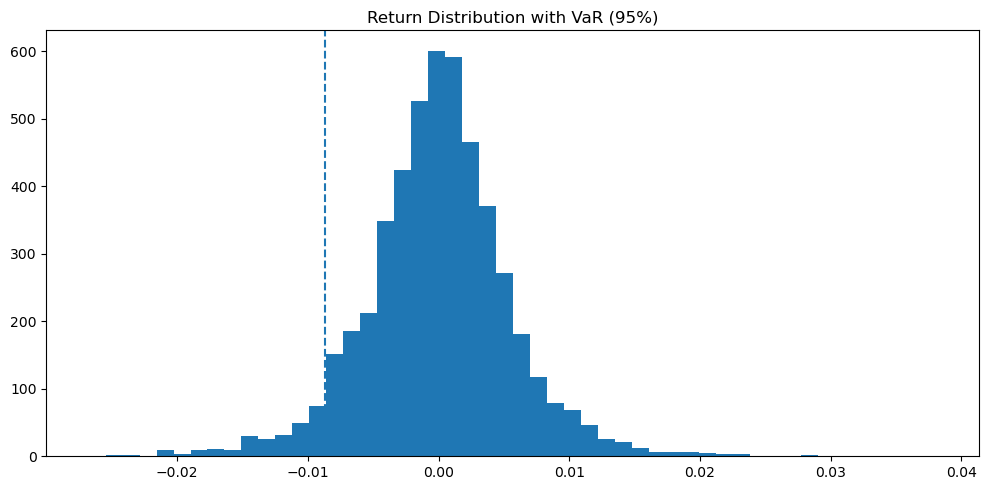

In [10]:
# Plot return distribution + VaR
plt.figure(figsize=(10, 5))
plt.hist(df["simple_return"].dropna(), bins=50)
plt.axvline(var_95, linestyle="--")
plt.title("Return Distribution with VaR (95%)")
plt.tight_layout()
plt.savefig("outputs/charts/day03_var_distribution.png")
plt.show()

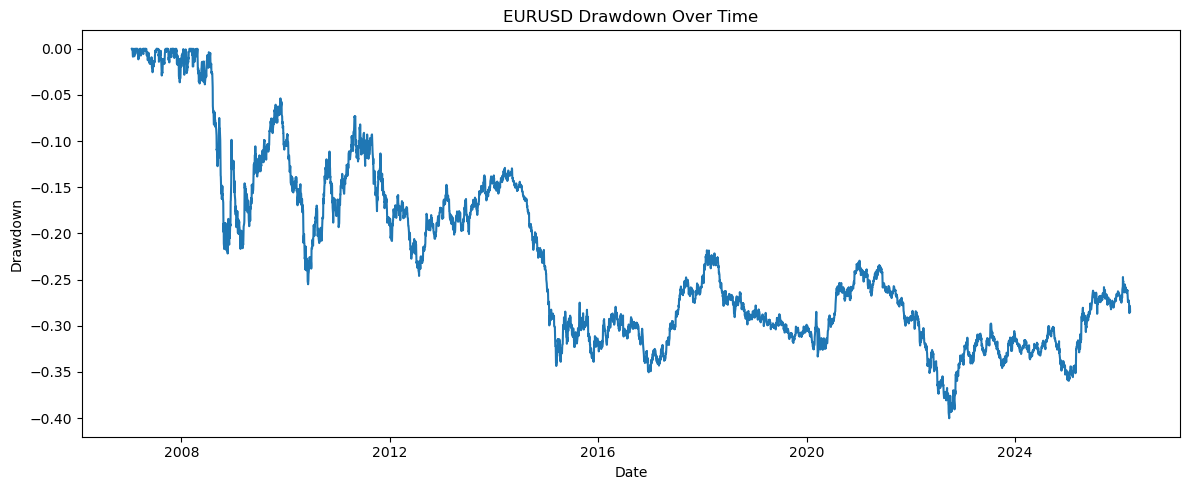

In [11]:
#Drawdown Analysis 
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["drawdown"])
plt.title("EURUSD Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.savefig("outputs/charts/day03_drawdown.png")
plt.show()

In [12]:
#Risk Summary Table
risk_summary = pd.DataFrame({
    "Metric": [
        "Daily Volatility",
        "Annualized Volatility",
        "Value at Risk (95%)",
        "Max Drawdown"
    ],
    "Value": [
        daily_vol,
        annual_vol,
        var_95,
        df["drawdown"].min()
    ]
})

risk_summary

,Metric,Value
0,Daily Volatility,0.005571
1,Annualized Volatility,0.088437
2,Value at Risk (95%),-0.008694
3,Max Drawdown,-0.400225


In [13]:
#Save File
risk_summary.to_csv("outputs/tables/day03_risk_summary.csv", index=False)

## Analyst Interpretation

This analysis focuses on understanding how risky the EURUSD market is and how that risk changes over time.

The rolling volatility chart shows that market risk is not constant. There are periods where volatility increases significantly, indicating higher uncertainty and more aggressive price movements. During these periods, trading becomes more unpredictable and potentially more dangerous, especially for traders without proper risk controls.

The return distribution chart, combined with the Value at Risk (VaR), provides insight into potential losses. The VaR line represents a threshold where extreme negative returns occur. In simple terms, it answers the question: *"How bad can a typical worst-case day be?"* This helps traders prepare for unfavorable market conditions rather than being caught off guard.

The drawdown chart highlights the real impact of holding a position over time. It shows how much value is lost from a previous peak during downturns. Even in a relatively stable market like EURUSD, there are noticeable periods of decline, emphasizing that losses are a natural part of trading.

Overall, the results show that market risk is dynamic and can change quickly. Periods of low volatility can suddenly shift into high-risk environments. This reinforces the importance of risk management, position sizing, and disciplined trading strategies.

Rather than focusing only on profits, this analysis demonstrates that understanding and controlling risk is essential for long-term success in financial markets.
## Key Takeaways
- Market risk is not constant; it changes over time
- High volatility periods increase uncertainty and potential losses  
- Extreme negative returns happen more often than expected  
- Drawdowns show that losses are unavoidable, even in stable markets  
- Risk management is just as important as finding profitable trades
## Conclusion

This project extends the analysis from price behavior and technical indicators to risk evaluation. Understanding volatility, downside risk, and drawdowns is essential for building robust trading strategies. These insights will be used in the next stage to design and test trading strategies with proper risk control.